# Entanglement-level statistics: nonequilibrium versus disordered equilibrium
Compare $N_x=20,N_y=32$, hard domain walls, $\alpha_1=1$, $\alpha_2=30$, $n_{\mathrm{shell}}=1$, with 100 pure-state realizations per ensemble. The nonequilibrium states are cycle-64 endpoints. The equilibrium states are half-filled ground states with independent zero-mean Gaussian potentials on diagonal entries $(x,y,\mu)$ only on $x=5,6,14,15$, zero elsewhere, of variance $W^2=1,2,3,4,6,9$. Use the same half-system $A_y=16$, fixed origin $y_0=0$, both orbitals, and $|\lambda|\le0.99$.

Within EACH realization, sort $\varepsilon=-2\operatorname{artanh}\lambda$ and compute
$$\delta_n=\varepsilon_{n+1}-\varepsilon_n,\qquad r_n=\frac{\min(\delta_n,\delta_{n+1})}{\max(\delta_n,\delta_{n+1})}.$$
Only afterward pool ratios. No spacing ever joins two different realizations. Histograms and means weight each valid ratio equally. Errors on the pooled mean delete whole realizations in a jackknife. No levels or near-degenerate pairs are merged. Report unresolved double-zero spacings and gaps below $10^{-6}$ separately.

The spacing histogram uses $\delta/\overline\delta$ within each realization; this removes an overall scale but is not full local unfolding. Ratio statistics do not require that scale normalization. The analyzed object is the single-particle entanglement spectrum, with no claim of many-body chaos. The full retained spectrum is analyzed without separating wall branches; reference ensembles are diagnostic comparisons, not assumed classifications.

The clean spectrum is a separate degeneracy control. Repeat ratios at $L=0.5,0.9,0.95$ and omit triples that straddle zero as sensitivity checks. Reference values: Poisson $\langle r\rangle=2\log2-1$; GUE approximately 0.5996 (large-matrix numerical value). The plotted GUE density is the 3-by-3 approximation from [Atas et al.](https://arxiv.org/abs/1212.5611), whose mean is approximately 0.60266. Entanglement-spectrum applications to disordered Chern insulators: [Prodan et al.](https://doi.org/10.1103/PhysRevLett.105.115501).

In [1]:
import os
CPU_RANGE=(8,15)
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[key]=str(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15]


## Configuration and inputs
Validate the saved spectra by checksum; no dynamics or ground-state diagonalization is repeated.

In [2]:
from pathlib import Path
import json,hashlib,subprocess
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display,Image
OUT=Path.cwd();BASE=OUT.parents[2]
SMALL=OUT.parent/'half_system_centered_spectrum_n20_sizes_hard_alpha1_v1'
EQ=BASE/'06_domain_wall_flattened_ground_state_reference/analysis_outputs/disordered_inner_wall_depth1_strength_scan_n20x32_v1'
L=.99
WINDOWS=[.5,.9,.95,.99]
ZERO_TOL=1e-12
PAIR_TOL=1e-6
def sha(p):
    with p.open('rb') as f:return hashlib.file_digest(f,'sha256').hexdigest()
inputs=[]
def verify(p,expected):
    digest=sha(p);assert digest==expected
    inputs.append({'path':str(p),'sha256':digest,'bytes':p.stat().st_size})
f=SMALL/'centered_spectra_Ny032.npz'
overlay=json.loads((SMALL/'overlay_diagnostics.json').read_text())
verify(f,overlay['sizes']['32']['spectra_sha256'])
with np.load(f) as z:
    assert np.array_equal(z['sample_ids'],np.arange(100))
    assert np.array_equal(z['subsystem_indices'],np.arange(640))
    arrays={'Nonequilibrium':z['eigenvalues']}
manifest=json.loads((EQ/'completion_manifest.json').read_text())
f=EQ/'spectra_and_energies.npz';verify(f,manifest['files'][f.name]['sha256'])
with np.load(f) as z:
    for i,v in enumerate(z['variances']):arrays[f'W2={v:g}']=z[f'centered_spectra_{i}']
f=EQ/'clean_reference.npz';verify(f,manifest['files'][f.name]['sha256'])
with np.load(f) as z:clean=z['centered_eigenvalues'][None,:]
for a in arrays.values():assert a.shape==(100,640)
assert clean.shape==(1,640)
labels=list(arrays)
OLD=OUT.parent/'entanglement_level_statistics_exact_wall_strength_scan_n20x32_L099_v1'
old_manifest=json.loads((OLD/'completion_manifest.json').read_text())
f=OLD/'distribution_comparison.csv'
verify(f,old_manifest['files'][f.name]['sha256'])
wall_only=pd.read_csv(f)
metadata={'Nx':20,'Ny':32,'Ay':16,'origin_y':0,'samples_per_ensemble':100,
 'L':L,'windows':WINDOWS,'disorder_inward_depth':1,'disorder_x_columns':[5,6,14,15],'zero_spacing_tolerance':ZERO_TOL,'near_pair_spacing_threshold':PAIR_TOL,
 'ratio_weighting':'pool ratios after computing within realizations',
 'error_bars':'one delete-realization jackknife standard error',
 'spacing_scaling':'divide each realization spacings by their mean; not local unfolding',
 'sector_handling':'full retained single-particle spectrum; no branch separation or pair merging'}
(OUT/'input_provenance.json').write_text(json.dumps({'configuration':metadata,'inputs':inputs,
 'equilibrium_provenance':json.loads((EQ/'input_provenance.json').read_text())},indent=2)+'\n')
display(pd.Series(metadata))

Nx                                                                            20
Ny                                                                            32
Ay                                                                            16
origin_y                                                                       0
samples_per_ensemble                                                         100
L                                                                           0.99
windows                                                   [0.5, 0.9, 0.95, 0.99]
disorder_inward_depth                                                          1
disorder_x_columns                                                [5, 6, 14, 15]
zero_spacing_tolerance                                                       0.0
near_pair_spacing_threshold                                             0.000001
ratio_weighting                  pool ratios after computing within realizations
error_bars                  

## Per-realization spacings and ratios
Compute moments and histograms from the original levels. All retained energies must be finite; unresolved ratios are counted explicitly.

In [3]:
def compute(a,window,label):
    ratio_rows=[];spacings=[];ratio_ids=[];sample_rows=[];same_sign=[]
    for sid,lam in enumerate(a):
        assert np.isfinite(lam).all() and np.max(np.abs(lam))<=1+1e-8
        selected=lam[np.abs(lam)<=window]
        e=np.sort(np.log1p(-selected)-np.log1p(selected))
        assert np.isfinite(e).all()
        d=np.diff(e)
        assert np.all(d>=0)
        if len(d):assert d.mean()>0
        den=np.maximum(d[:-1],d[1:])
        valid=den>ZERO_TOL
        r=np.minimum(d[:-1],d[1:])[valid]/den[valid]
        assert np.all((r>=0)&(r<=1))
        same=(e[:-2]*e[2:]>0)[valid]
        same_sign.extend(r[same])
        ratio_rows.extend(r);ratio_ids.extend([sid]*len(r));spacings.extend(d/d.mean() if len(d) else [])
        sample_rows.append({'ensemble':label,'L':window,'sample_id':sid,'levels':len(e),
           'ratio_count':len(r),'ratio_sum':float(r.sum()),'mean_r':float(r.mean()) if len(r) else None,
           'spacing_count':len(d),'mean_spacing':float(d.mean()) if len(d) else None,
           'near_pair_gaps':int((d<PAIR_TOL).sum()),'unresolved_ratios':int((~valid).sum())})
    r=np.array(ratio_rows);ids=np.array(ratio_ids,dtype=int)
    assert len(r)>0
    n=np.bincount(ids,minlength=len(a));s=np.bincount(ids,weights=r,minlength=len(a))
    se=None
    if len(a)>1:
        leave=(s.sum()-s)/(n.sum()-n)
        se=float(np.sqrt((len(a)-1)/len(a)*np.sum((leave-leave.mean())**2)))
    row={'ensemble':label,'L':window,'samples':len(a),'total_levels':sum(x['levels'] for x in sample_rows),
         'realizations_with_ratios':int(np.count_nonzero(n)),
         'ratio_count':len(r),'mean_r':float(r.mean()) if len(r) else None,'mean_r_jackknife_se':se,
         'same_sign_mean_r':float(np.mean(same_sign)),'same_sign_ratio_count':len(same_sign),
         'near_pair_gaps':sum(x['near_pair_gaps'] for x in sample_rows),
         'unresolved_ratios':sum(x['unresolved_ratios'] for x in sample_rows)}
    return r,np.array(spacings),ids,row,sample_rows
results={};summary_rows=[];sample_rows=[];cache={};sensitivity=[]
for i,(label,a) in enumerate(tqdm(arrays.items(),desc='Level statistics',unit='ensemble')):
    for window in WINDOWS:
        r,s,ids,row,sr=compute(a,window,label)
        sensitivity.append(row)
        if window==L:
            results[label]={'ratios':r,'spacings':s,'sample_ids':ids}
            summary_rows.append(row);sample_rows.extend(sr)
            cache[f'ratios_{i}']=r;cache[f'spacings_{i}']=s;cache[f'sample_ids_{i}']=ids
r,s,ids,clean_summary,sr=compute(clean,L,'Clean control')
cache['clean_ratios']=r;cache['clean_spacings']=s
summary=pd.DataFrame(summary_rows)
summary.to_csv(OUT/'level_statistics_summary.csv',index=False)
pd.DataFrame(sample_rows).to_csv(OUT/'sample_level_statistics.csv',index=False)
pd.DataFrame(sensitivity).to_csv(OUT/'window_sensitivity.csv',index=False)
np.savez_compressed(OUT/'level_statistics.npz',**cache,labels=labels,L=L)
display(summary[['ensemble','ratio_count','mean_r','mean_r_jackknife_se','near_pair_gaps']])
print('Clean degeneracy control:',clean_summary)

Level statistics:   0%|          | 0/7 [00:00<?, ?ensemble/s]

,ensemble,ratio_count,mean_r,mean_r_jackknife_se,near_pair_gaps
0,Nonequilibrium,2920,0.902384,0.011521,0
1,W2=1,2807,0.974351,0.000460,0
2,W2=2,2798,0.967451,0.001677,0
3,W2=3,2796,0.956268,0.002493,0
4,W2=4,2778,0.945207,0.002365,0
5,W2=6,2785,0.922972,0.003053,0
6,W2=9,2742,0.911737,0.003636,0


Clean degeneracy control: {'ensemble': 'Clean control', 'L': 0.99, 'samples': 1, 'total_levels': 30, 'realizations_with_ratios': 1, 'ratio_count': 28, 'mean_r': 2.4177641922986454e-07, 'mean_r_jackknife_se': None, 'same_sign_mean_r': 2.418218125390185e-07, 'same_sign_ratio_count': 26, 'near_pair_gaps': 15, 'unresolved_ratios': 0}


## Distribution comparison without histogram binning
For each disorder strength, compare the empirical cumulative distribution $F_W(R)$ to the nonequilibrium distribution $F_{\rm NE}(R)$:
$$D_{\rm area}=\int_0^1 |F_W(R)-F_{\rm NE}(R)|\,dR,\qquad D_{\max}=\sup_R|F_W(R)-F_{\rm NE}(R)|.$$
The first is the one-dimensional Wasserstein distance; the second is the Kolmogorov distance. Both vanish for identical distributions. Evaluate them exactly from the unbinned ratios. No exponential, cycloid, or other shape is assumed. Ratios within a realization overlap and are correlated: uncertainty resamples whole realizations independently in each ensemble, retaining the ratio-weighted estimator. Report 95% percentile bootstrap intervals, not independent-level p-values. The nearest tested strength is an exploratory selection on this same data, not a fitted effective theory or an equivalence test.

In [4]:
BOOTSTRAPS=1000
BOOTSTRAP_SEED=2026092704
from scipy.stats import wasserstein_distance, ks_2samp
rng=np.random.default_rng(BOOTSTRAP_SEED)
strengths=np.array([float(label.split('=')[1]) for label in labels[1:]])
ne=results['Nonequilibrium']
ref_mult=rng.multinomial(100,np.full(100,.01),size=BOOTSTRAPS)
def prep(label):
    v=results[label];order=np.argsort(v['ratios'],kind='stable')
    return v['ratios'][order],v['sample_ids'][order]
ref_r,ref_ids=prep('Nonequilibrium')
def cdf_mass(sorted_ids,indices,mult):
    weights=mult[sorted_ids]
    return np.r_[0,np.cumsum(weights)][indices]/weights.sum()
distance_rows=[];boot_area=[];boot_max=[];cdf_rows=[]
for label,var in tqdm(list(zip(labels[1:],strengths)),desc='Compare full distributions',unit='strength'):
    rr,ids=prep(label)
    grid=np.unique(np.r_[0,ref_r,rr,1])
    ir=np.searchsorted(ref_r,grid,side='right')
    ie=np.searchsorted(rr,grid,side='right')
    fref=cdf_mass(ref_ids,ir,np.ones(100))
    feq=cdf_mass(ids,ie,np.ones(100))
    diff=np.abs(feq-fref);width=np.diff(grid)
    area=float(np.dot(diff[:-1],width));maximum=float(diff.max())
    assert 0<=area<=1 and 0<=maximum<=1
    assert np.isclose(area,wasserstein_distance(ref_r,rr),rtol=0,atol=1e-14)
    assert np.isclose(maximum,ks_2samp(ref_r,rr,method='asymp').statistic,rtol=0,atol=1e-14)
    vals=np.empty((BOOTSTRAPS,2))
    eq_mult=rng.multinomial(100,np.full(100,.01),size=BOOTSTRAPS)
    for b in range(BOOTSTRAPS):
        delta=np.abs(cdf_mass(ids,ie,eq_mult[b])-cdf_mass(ref_ids,ir,ref_mult[b]))
        vals[b]=np.dot(delta[:-1],width),delta.max()
    lo,hi=np.quantile(vals,[.025,.975],axis=0)
    distance_rows.append({'ensemble':label,'variance':var,'std':np.sqrt(var),
        'cdf_area_distance':area,'cdf_area_ci_low':lo[0],'cdf_area_ci_high':hi[0],
        'cdf_max_distance':maximum,'cdf_max_ci_low':lo[1],'cdf_max_ci_high':hi[1]})
    boot_area.append(vals[:,0]);boot_max.append(vals[:,1])
    cdf_rows.extend({'ensemble':label,'R':r,'cdf_equilibrium':a,'cdf_nonequilibrium':b}
                    for r,a,b in zip(grid,feq,fref))
distances=pd.DataFrame(distance_rows)
comparison=distances.merge(summary,on='ensemble',validate='one_to_one')
comparison.to_csv(OUT/'distribution_comparison.csv',index=False)
support_comparison=comparison[['variance','mean_r','mean_r_jackknife_se','cdf_area_distance','cdf_max_distance']].merge(
    wall_only[['variance','mean_r','mean_r_jackknife_se','cdf_area_distance','cdf_max_distance']],
    on='variance',suffixes=('_inward1','_wall_only'),validate='one_to_one')
support_comparison.to_csv(OUT/'support_comparison.csv',index=False)
pd.DataFrame(cdf_rows).to_csv(OUT/'empirical_cdf_comparison.csv',index=False)
np.savez_compressed(OUT/'distribution_bootstrap.npz',variances=strengths,
    cdf_area=np.array(boot_area),cdf_max=np.array(boot_max),
    seed=BOOTSTRAP_SEED,replicates=BOOTSTRAPS)
best_label=distances.loc[distances.cdf_area_distance.idxmin(),'ensemble']
print('Closest tested strength by CDF area:',best_label)
display(comparison[['variance','mean_r','mean_r_jackknife_se','cdf_area_distance','cdf_max_distance']])

Compare full distributions:   0%|          | 0/6 [00:00<?, ?strength/s]

Closest tested strength by CDF area: W2=9


,variance,mean_r,mean_r_jackknife_se,cdf_area_distance,cdf_max_distance
0,1.0,0.974351,0.000460,0.071966,0.327526
1,2.0,0.967451,0.001677,0.065067,0.268465
2,3.0,0.956268,0.002493,0.053892,0.197374
3,4.0,0.945207,0.002365,0.042823,0.142737
4,6.0,0.922972,0.003053,0.020588,0.056632
5,9.0,0.911737,0.003636,0.011158,0.030138


## Gap-ratio histograms
Each panel compares one equilibrium disorder strength with the same nonequilibrium reference. Both are normalized to unit area. Change R_BINS to rebin without recomputing spectra or distribution distances.

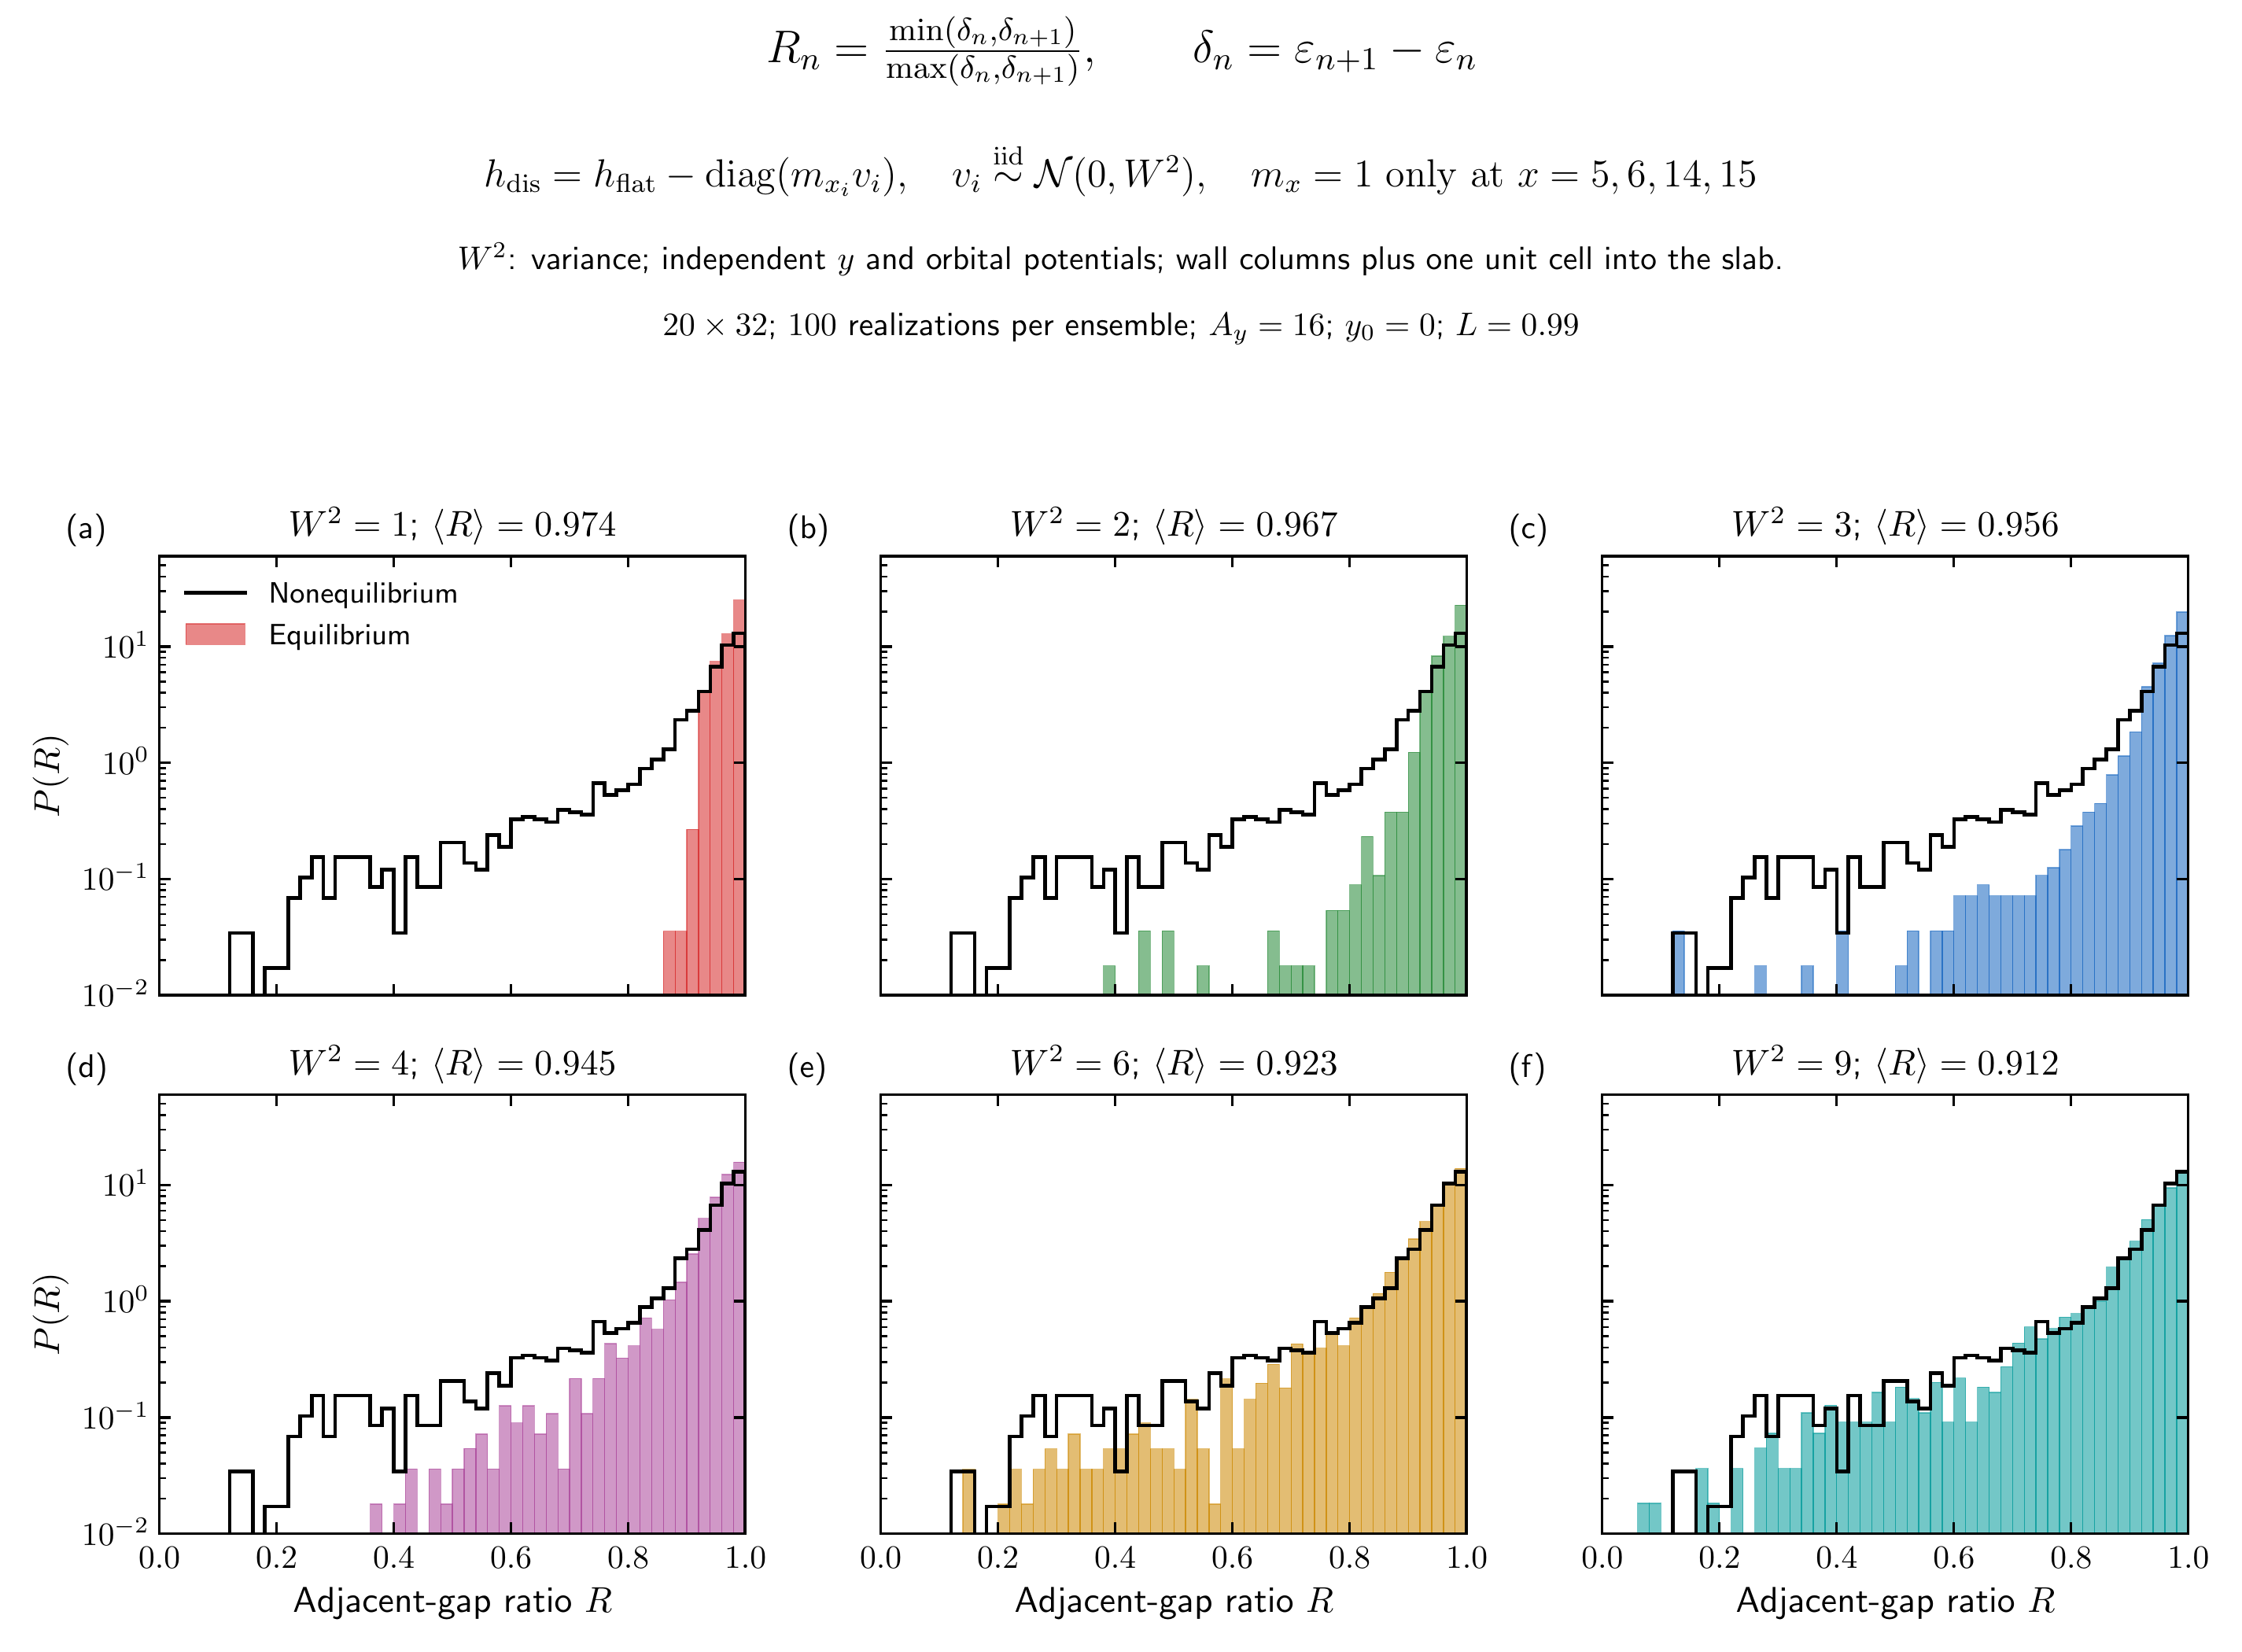

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],
 'font.size':10,'axes.labelsize':11,'axes.titlesize':11,'xtick.labelsize':10,'ytick.labelsize':10,
 'text.usetex':True,'text.latex.preamble':r'\usepackage{amsmath,amssymb}',
 'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in',
 'legend.fontsize':9,'legend.frameon':False})
R_BINS=50
redges=np.linspace(0,1,R_BINS+1)
colors=['#d62728','#228833','#1565c0','#aa4499','#cc8800','#009999']
hist_rows=[]
density={}
for label in labels:
    n,_=np.histogram(results[label]['ratios'],redges)
    rho=n/(len(results[label]['ratios'])*np.diff(redges))
    assert n.sum()==len(results[label]['ratios']) and np.isclose(np.dot(rho,np.diff(redges)),1)
    density[label]=rho
    hist_rows.extend({'ensemble':label,'left':redges[j],'right':redges[j+1],
                      'count':int(n[j]),'density':float(rho[j])} for j in range(R_BINS))
pd.DataFrame(hist_rows).to_csv(OUT/'ratio_histograms.csv',index=False)
fig,axes=plt.subplots(2,3,figsize=(9.5,7.0),sharex=True,sharey=True)
for ax,label,var,color,letter in zip(axes.flat,labels[1:],strengths,colors,'abcdef'):
    rho=density[label];nz=rho>0
    ax.bar(redges[:-1][nz],rho[nz],width=np.diff(redges)[nz],align='edge',
           color=color,alpha=.55,edgecolor=color,linewidth=.3,label='Equilibrium')
    ax.stairs(density['Nonequilibrium'],redges,color='black',lw=1.1,label='Nonequilibrium')
    mean=summary.set_index('ensemble').loc[label,'mean_r']
    ax.set(title=rf'$W^2={var:g}$; $\langle R\rangle={mean:.3f}$',xlim=(0,1),ylim=(.01,60),yscale='log')
    ax.tick_params(top=True,right=True)
    ax.text(-.16,1.04,f'({letter})',transform=ax.transAxes,fontweight='bold')
axes[0,0].legend(loc='upper left')
for ax in axes[-1]:ax.set_xlabel(r'Adjacent-gap ratio $R$')
for ax in axes[:,0]:ax.set_ylabel(r'$P(R)$')
fig.suptitle(r'$R_n=\frac{\min(\delta_n,\delta_{n+1})}{\max(\delta_n,\delta_{n+1})},'
              r'\qquad \delta_n=\varepsilon_{n+1}-\varepsilon_n$',fontsize=14,y=.99)
fig.text(.5,.887,r'$h_{\rm dis}=h_{\rm flat}-\mathrm{diag}(m_{x_i}v_i),'
         r'\quad v_i\overset{\rm iid}{\sim}\mathcal{N}(0,W^2),'
         r'\quad m_x=1\ \mathrm{only\ at}\ x=5,6,14,15$',ha='center',fontsize=12)
fig.text(.5,.837,r'$W^2$: variance; independent $y$ and orbital potentials; wall columns plus one unit cell into the slab.',
         ha='center',fontsize=10)
fig.text(.5,.797,r'$20\times32$; $100$ realizations per ensemble; $A_y=16$; $y_0=0$; $L=0.99$',
         ha='center',fontsize=10)
fig.tight_layout(pad=1,rect=(0,0,1,.775))
fig.savefig(OUT/'gap_ratio_distributions.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'gap_ratio_distributions.pdf'),str(OUT/'gap_ratio_distributions')],check=True)
display(Image(filename=str(OUT/'gap_ratio_distributions.png'),width=1100))

## Disorder dependence of the mean and full distribution
Gray triangles reproduce the exact-wall scan for comparison. Left: mean ratio, with one-SE realization-jackknife error bars and the nonequilibrium mean plus its one-SE band. Right: maximum separation between CDFs; vertical bars mark 95% whole-realization bootstrap percentile intervals. Smaller distance means closer empirical distributions.

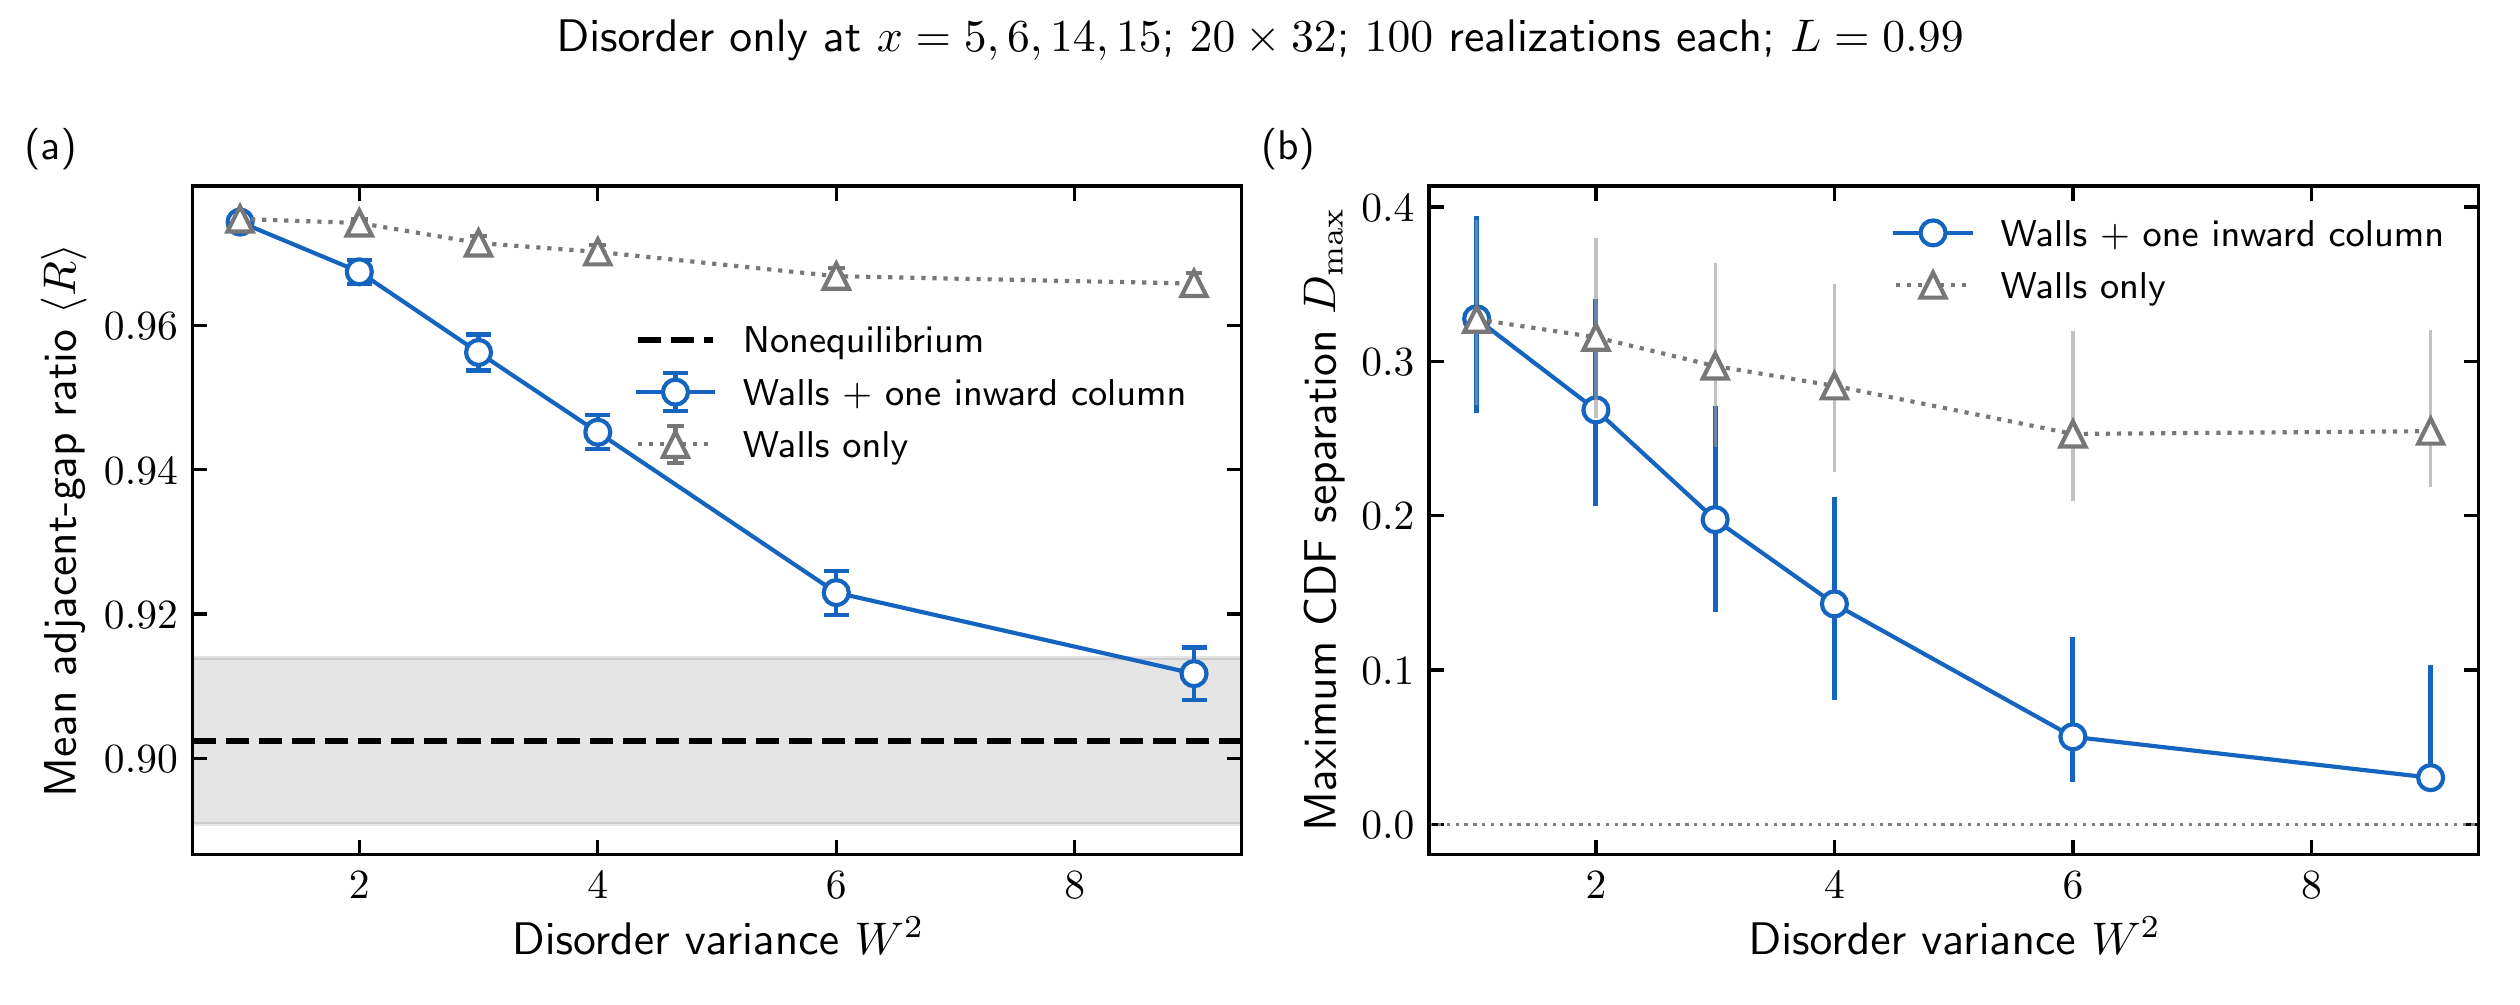

In [6]:
fig,axes=plt.subplots(1,2,figsize=(8.4,3.35))
eq=summary.set_index('ensemble').loc[labels[1:]]
ne_row=summary.set_index('ensemble').loc['Nonequilibrium']
ax=axes[0]
ax.errorbar(strengths,eq.mean_r,yerr=eq.mean_r_jackknife_se,fmt='o-',color='#1565c0',
            mfc='white',capsize=3,lw=1,label='Walls + one inward column')
ax.errorbar(wall_only.variance,wall_only.mean_r,yerr=wall_only.mean_r_jackknife_se,
            fmt='^:',color='#777777',mfc='white',capsize=2,lw=1,label='Walls only')
ax.axhline(ne_row.mean_r,color='black',ls='--',label='Nonequilibrium')
ax.axhspan(ne_row.mean_r-ne_row.mean_r_jackknife_se,ne_row.mean_r+ne_row.mean_r_jackknife_se,
           color='black',alpha=.10)
ax.set(xlabel=r'Disorder variance $W^2$',ylabel=r'Mean adjacent-gap ratio $\langle R\rangle$')
ax.legend(loc='upper right',bbox_to_anchor=(.98,.84))
ax=axes[1]
ax.vlines(strengths,distances.cdf_max_ci_low,distances.cdf_max_ci_high,color='#1565c0',lw=1.2)
ax.plot(strengths,distances.cdf_max_distance,'o-',color='#1565c0',mfc='white',lw=1,label='Walls + one inward column')
ax.vlines(wall_only.variance,wall_only.cdf_max_ci_low,wall_only.cdf_max_ci_high,color='#999999',alpha=.6,lw=.8)
ax.plot(wall_only.variance,wall_only.cdf_max_distance,'^:',color='#777777',mfc='white',lw=1,label='Walls only')
ax.legend(loc='best')
ax.axhline(0,color='gray',ls=':',lw=.8)
ax.set(xlabel=r'Disorder variance $W^2$',ylabel=r'Maximum CDF separation $D_{\max}$')
for ax,letter in zip(axes,'ab'):
    ax.tick_params(top=True,right=True)
    ax.text(-.16,1.04,f'({letter})',transform=ax.transAxes,fontweight='bold')
fig.suptitle(r'Disorder only at $x=5,6,14,15$; $20\times32$; $100$ realizations each; $L=0.99$',fontsize=11)
fig.tight_layout(pad=1)
fig.savefig(OUT/'disorder_scan_comparison.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'disorder_scan_comparison.pdf'),str(OUT/'disorder_scan_comparison')],check=True)
display(Image(filename=str(OUT/'disorder_scan_comparison.png'),width=1000))

## Closest tested distribution
This strength minimizes the empirical CDF area among the six tested strengths. Selection and assessment use the same data; similarity is not evidence of an identical distribution or effective theory.

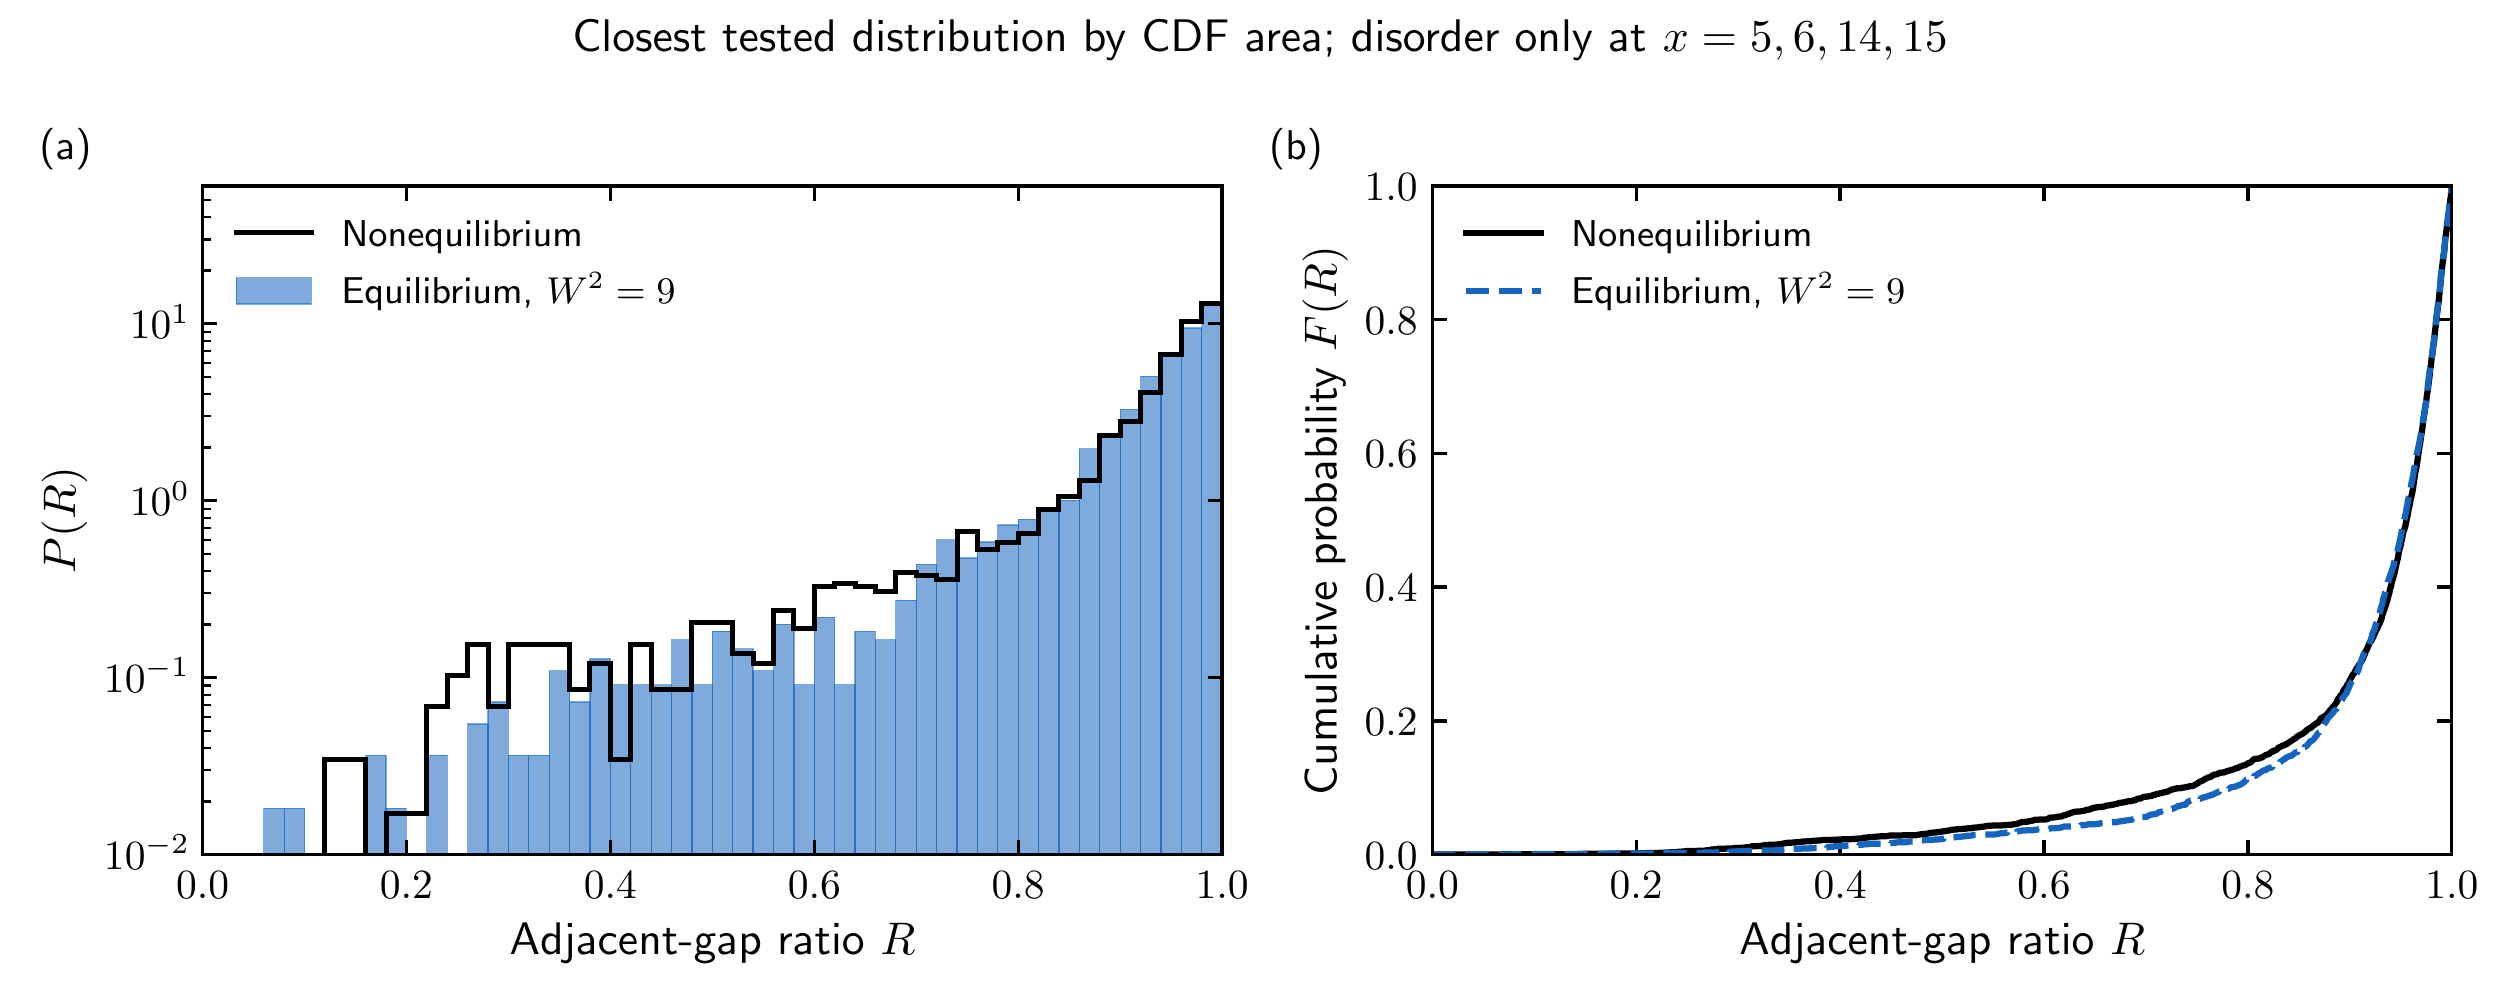

In [7]:
var=float(best_label.split('=')[1])
fig,axes=plt.subplots(1,2,figsize=(8.4,3.35))
ax=axes[0]
rr=density[best_label];nz=rr>0
ax.bar(redges[:-1][nz],rr[nz],width=np.diff(redges)[nz],align='edge',color='#1565c0',alpha=.55,
       edgecolor='#1565c0',linewidth=.3,label=rf'Equilibrium, $W^2={var:g}$')
ax.stairs(density['Nonequilibrium'],redges,color='black',lw=1.2,label='Nonequilibrium')
ax.set(xlim=(0,1),yscale='log',ylim=(.01,60),xlabel=r'Adjacent-gap ratio $R$',ylabel=r'$P(R)$')
ax.legend(loc='upper left')
ax=axes[1]
for label,color,ls in [('Nonequilibrium','black','-'),(best_label,'#1565c0','--')]:
    a=np.sort(results[label]['ratios'])
    ax.step(np.r_[0,a,1],np.r_[0,np.arange(1,len(a)+1)/len(a),1],where='post',
            color=color,ls=ls,label='Nonequilibrium' if label=='Nonequilibrium' else rf'Equilibrium, $W^2={var:g}$')
ax.set(xlim=(0,1),ylim=(0,1),xlabel=r'Adjacent-gap ratio $R$',ylabel=r'Cumulative probability $F(R)$')
ax.legend(loc='upper left')
for ax,letter in zip(axes,'ab'):
    ax.tick_params(top=True,right=True)
    ax.text(-.16,1.04,f'({letter})',transform=ax.transAxes,fontweight='bold')
fig.suptitle(r'Closest tested distribution by CDF area; disorder only at $x=5,6,14,15$',fontsize=11)
fig.tight_layout(pad=1)
fig.savefig(OUT/'closest_distribution.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'closest_distribution.pdf'),str(OUT/'closest_distribution')],check=True)
display(Image(filename=str(OUT/'closest_distribution.png'),width=1000))

## Spacing distributions
Gaps are divided by the mean gap of their own realization, without full local unfolding. Each panel contains one equilibrium strength and the nonequilibrium reference.

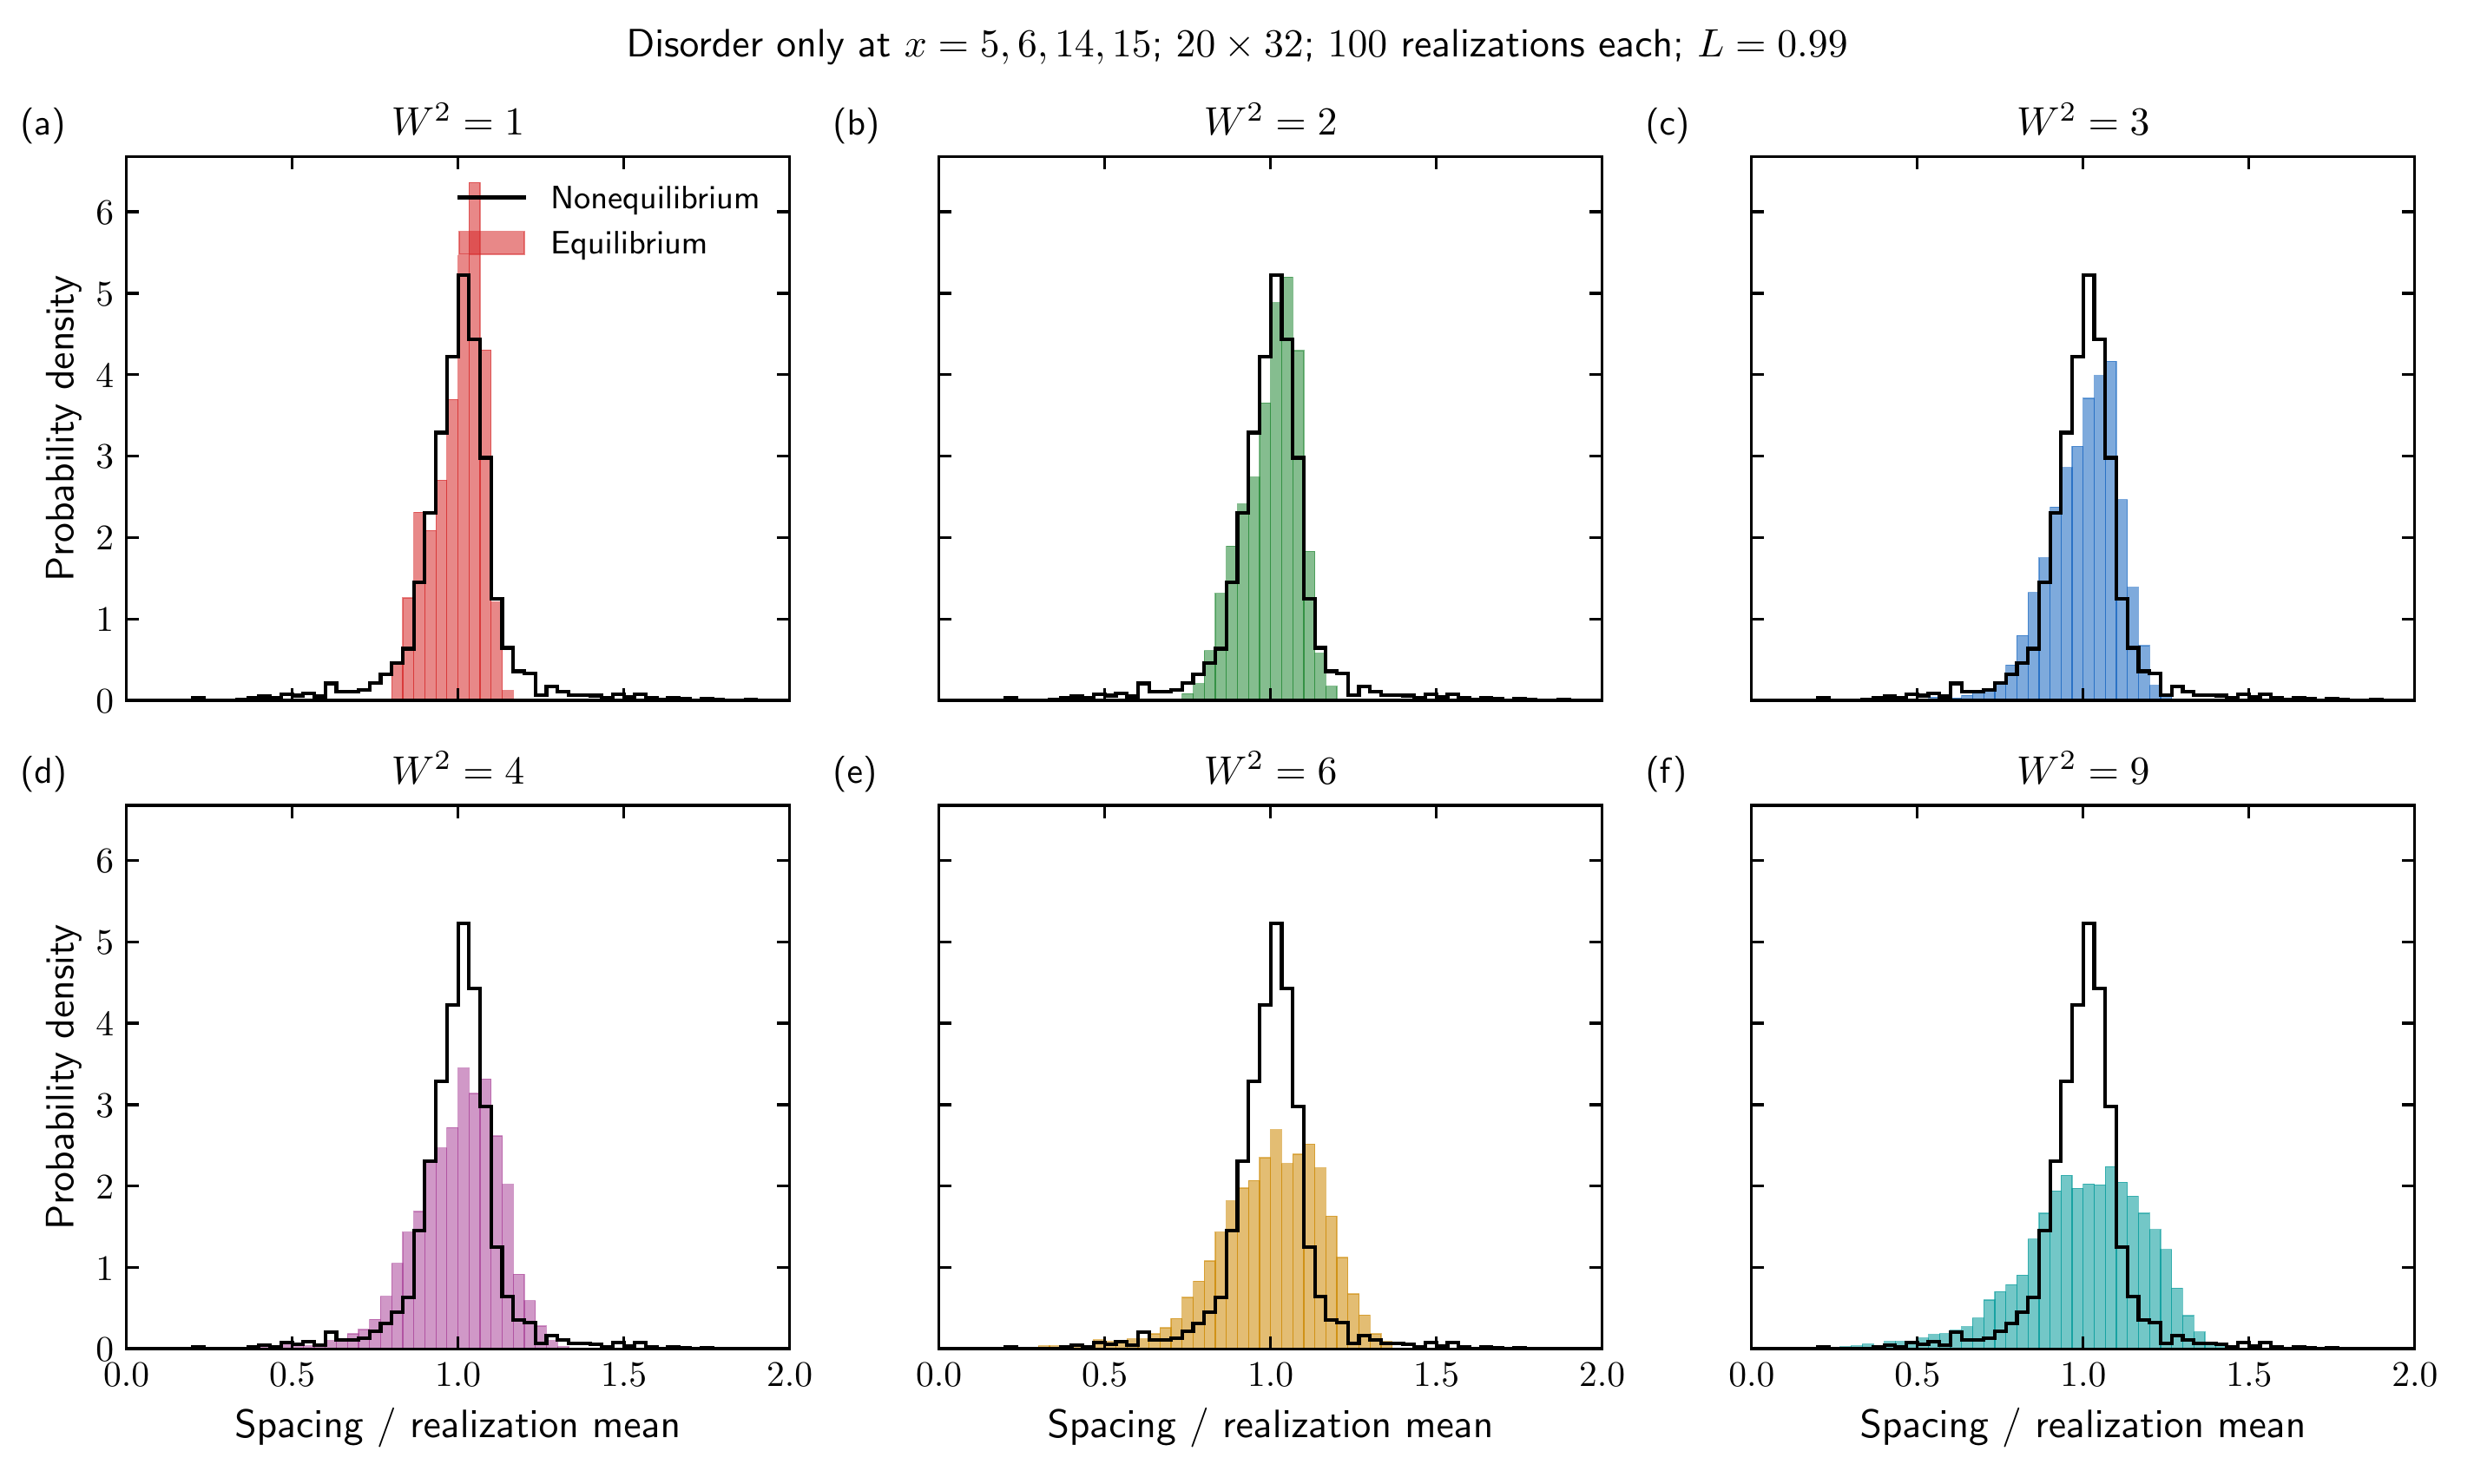

In [8]:
spacing_max=max(2.,float(np.ceil(max(np.max(v['spacings']) for v in results.values()))))
edges=np.linspace(0,spacing_max,61);spacing_rows=[];spacing_density={}
for label in labels:
    a=results[label]['spacings'];n,_=np.histogram(a,edges)
    rho=n/(len(a)*np.diff(edges));assert n.sum()==len(a)
    spacing_density[label]=rho
    spacing_rows.extend({'ensemble':label,'left':edges[j],'right':edges[j+1],
                         'count':int(n[j]),'density':float(rho[j])} for j in range(len(n)))
pd.DataFrame(spacing_rows).to_csv(OUT/'spacing_histograms.csv',index=False)
fig,axes=plt.subplots(2,3,figsize=(9.5,5.7),sharex=True,sharey=True)
for ax,label,var,color,letter in zip(axes.flat,labels[1:],strengths,colors,'abcdef'):
    ax.bar(edges[:-1],spacing_density[label],width=np.diff(edges),align='edge',
           color=color,alpha=.55,edgecolor=color,linewidth=.3,label='Equilibrium')
    ax.stairs(spacing_density['Nonequilibrium'],edges,color='black',lw=1,label='Nonequilibrium')
    ax.set(title=rf'$W^2={var:g}$',xlim=(0,spacing_max))
    ax.tick_params(top=True,right=True)
    ax.text(-.16,1.04,f'({letter})',transform=ax.transAxes,fontweight='bold')
axes[0,0].legend()
for ax in axes[-1]:ax.set_xlabel('Spacing / realization mean')
for ax in axes[:,0]:ax.set_ylabel('Probability density')
fig.suptitle(r'Disorder only at $x=5,6,14,15$; $20\times32$; $100$ realizations each; $L=0.99$',fontsize=11)
fig.tight_layout(pad=1)
fig.savefig(OUT/'spacing_distributions.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'spacing_distributions.pdf'),str(OUT/'spacing_distributions')],check=True)
display(Image(filename=str(OUT/'spacing_distributions.png'),width=1100))

## Diagnostics and sensitivity
All distances use unbinned ratios computed within realizations. No pair merging or independent-level significance test is used. Narrow-window spectra with fewer than three levels contribute zero ratios and are counted explicitly.

In [9]:
diagnostics={'configuration':metadata,'ensembles':summary_rows,'clean_control':clean_summary,
 'sensitivity':sensitivity,'distribution_comparison':distance_rows,'closest_tested_by_cdf_area':best_label,
 'bootstrap':{'replicates':BOOTSTRAPS,'seed':BOOTSTRAP_SEED,'unit':'whole realization',
 'interval':'95% percentile','shared_nonequilibrium_resamples_across_strengths':True},
 'checks':{'within_realization_spacings_only':True,'no_pair_merging':True,
 'ratio_histograms_unit_area':True,'input_checksums':True,'cdf_distances_crosschecked_with_scipy':True},
 'scope':'descriptive single-particle entanglement statistics; same-data strength selection; no equivalence or universality claim'}
(OUT/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(pd.DataFrame(sensitivity)[['ensemble','L','mean_r','same_sign_mean_r','realizations_with_ratios']])
print('Complete: 600 inward-extended wall ground states and 100 nonequilibrium spectra compared.')

,ensemble,L,mean_r,same_sign_mean_r,realizations_with_ratios
0,Nonequilibrium,0.50,0.901633,0.899892,100
1,Nonequilibrium,0.90,0.902427,0.902167,100
2,Nonequilibrium,0.95,0.903937,0.903911,100
3,Nonequilibrium,0.99,0.902384,0.902254,100
4,W2=1,0.50,0.985538,0.984409,100
5,W2=1,0.90,0.983993,0.983549,100
6,W2=1,0.95,0.984473,0.984195,100
7,W2=1,0.99,0.974351,0.973403,100
8,W2=2,0.50,0.976551,0.973900,100
9,W2=2,0.90,0.973931,0.973055,100


Complete: 600 inward-extended wall ground states and 100 nonequilibrium spectra compared.
